# HAR elastic net — recency weighting × window length (3D QLIKE surfaces)

Companion to `HAR_RegressionWithElasticNet_WindowSweep.ipynb`. That notebook fit the elastic
net on a **plain, equally-weighted** rolling window. This one adds a **recency-decay factor δ**:
each observation in the window is weighted `δ^age` (newest row age 0 → weight 1; oldest →
`δ^(W-1)`), so `δ < 1` tilts the fit toward recent observations and `δ = 1` recovers the
unweighted base case. Weights are normalised to mean 1 so `alpha`'s penalty scale stays
comparable across δ.

**λ selection is honest / real-time** (no look-ahead). For each forecast day we choose the
penalty `alpha` by **walk-forward cross-validation inside that day's rolling window**: 3 expanding
folds, each validating on the next 20% block —

- fold 1: train on rows [0, 40%) → validate on [40%, 60%)
- fold 2: train on rows [0, 60%) → validate on [60%, 80%)
- fold 3: train on rows [0, 80%) → validate on [80%, 100%)

For each candidate `alpha` we score **QLIKE-in-levels** (the same loss the model is judged on out
of sample) on each held-out block and pick the `alpha` that minimises the **average QLIKE across
the 3 folds**, then refit at that `alpha` on the full recency-weighted window. `l1_ratio` is
**fixed at 0.1** (the near-ridge value that won at every window/spec previously). Each fold trains
only on rows strictly older than its validation block, so there is no look-ahead, and this replaces
the earlier oracle rule (a single global `alpha` picked to minimise the realised OOS QLIKE) — the
elastic net no longer enjoys a look-ahead advantage over the OLS baseline. Every window is scored
on the **same common out-of-sample period** so only window length and δ change.

**Retransformation (log → level): standard unweighted Duan (1983) smearing**, i.e.
`level = exp(x'β̂) · mean(exp(residual))`, applied identically to OLS, recency-weighted OLS, and the
elastic net. The smearing factor is an *equal-weighted* mean of the in-window exponentiated
residuals — Duan's estimand under additive homoskedastic errors; there is no canonical *weighted*
Duan. The recency weighting δ enters the **fit (β)** only, not the smearing average.

**Benchmark in one place.** Alongside the elastic-net cube we compute a **recency-weighted OLS
(WLS)** cube on the *same* δ×window grid and the *same* retransformation, then plot the **EN − OLS
difference surface** per spec (z<0 ⇒ honest EN beats weighted OLS). The window grid is extended to
**5y** and δ refined near **0.995** (where the earlier minima sat on the grid edge).

The sweep runs windows **1y…5y** and δ **[1.0, 0.999, 0.997, 0.996, 0.995, 0.994, 0.993, 0.992,
0.99, 0.97]**. The result is, per spec, a 3D EN QLIKE surface (x = window, y = δ, z = walk-forward-CV
EN QLIKE) plus the EN − OLS difference surface — answering whether any recency tilt lets the
regularised model beat plain recency-weighted OLS.

Same three specs as the source notebook (logged HAR + logged exogenous day-t terms, Duan-smearing
log→level back-transform, QLIKE-in-levels scoring):
- **Run 18** — log HAR + log GVZ
- **Run 19** — log HAR + log SPX (RV_ES) + log GVZ
- **Run 20** — log HAR + log crude (RV_crude) + log GVZ

In [ ]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables projection="3d")
from sklearn.linear_model import ElasticNet, enet_path
from sklearn.preprocessing import StandardScaler

# Same aligned daily realized-variance panel used by SimpleHAR_Regressions.ipynb
data = pd.read_parquet("merged_RV_GVZ.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW_YEARS = np.array([4.5, 5.0,5.5,6.0,6.5,7.0])   # extended grid (to 5y)
WINDOWS = [int(round(yr * TRADING_DAYS)) for yr in WINDOW_YEARS]
WINDOW_DEFAULT = 504          # 2y, used for the sanity-check cell
EPS = 1e-6                    # QLIKE forecast floor

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"Columns available: {list(data.columns)}")
print(f"Window lengths (days): {WINDOWS}")

RV_gold: 4114 obs, 2010-01-04 .. 2026-05-29
Columns available: ['RV_gold', 'RV_crude', 'RV_ES', 'GVZ_close']
Window lengths (days): [252, 378, 504, 630, 756, 882, 1008, 1134, 1260]


In [2]:
# ===========================================================================
# Cell 2 — Build the 3 log+GVZ design tables (mirror SimpleHAR Cells 7 & 11)
# ===========================================================================
# Log-HAR components on x = log(RV_gold):
#   x_d[t]=x_t, x_w[t]=mean(x_{t-4..t}), x_m[t]=mean(x_{t-21..t})
#   y_log[t]=x_{t+1}=log(RV_{t+1}); y_level[t]=RV_{t+1} (kept for QLIKE in levels).
# Exogenous day-t terms are logged and known at the close (no look-ahead).

# Strict positivity required for every logged input
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    """Base log-HAR design + optional logged exogenous day-t columns (dict name->series)."""
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)        # log(RV_{t+1})
    df["y_level"] = rv.shift(-1)       # RV_{t+1} in levels, for QLIKE
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])

# Run 18 / 19 / 20 design tables
d_gvz       = build_log_design({"log_GVZ": log_gvz})
d_spx_gvz   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx})
d_crude_gvz = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude})

for name, df in [("d_gvz", d_gvz), ("d_spx_gvz", d_spx_gvz), ("d_crude_gvz", d_crude_gvz)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 18  log+GVZ        cols:", list(d_gvz.columns),       f"({len(d_gvz)} rows)")
print("Run 19  log+SPX+GVZ    cols:", list(d_spx_gvz.columns),   f"({len(d_spx_gvz)} rows)")
print("Run 20  log+crude+GVZ  cols:", list(d_crude_gvz.columns), f"({len(d_crude_gvz)} rows)")
d_gvz.head()

Run 18  log+GVZ        cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'y_log', 'y_level'] (4092 rows)
Run 19  log+SPX+GVZ    cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_ES', 'y_log', 'y_level'] (4092 rows)
Run 20  log+crude+GVZ  cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'y_log', 'y_level'] (4092 rows)


,x_d,x_w,x_m,log_GVZ,y_log,y_level
Date,,,,,,
2010-02-03,2.850663,2.981362,2.933665,3.095125,3.580491,35.891145
2010-02-04,3.580491,3.080406,2.967351,3.302849,3.444815,31.337489
2010-02-05,3.444815,3.158204,2.994161,3.317453,2.911737,18.388714
2010-02-08,2.911737,3.146146,2.996290,3.291383,2.940123,18.918172
2010-02-09,2.940123,3.145566,3.005753,3.236716,3.123939,22.735769


In [3]:
# ===========================================================================
# Cell 3 — Helpers: QLIKE, common-OOS start, OLS / recency-weighted-OLS baselines,
#          per-day EN λ-selection
# ===========================================================================
# Common out-of-sample period: every window length is scored on the SAME forecast
# dates (those on/after the longest window has warmed up), so differences reflect
# window length only — mirrors the SimpleHAR_Regressions.ipynb window sweep.
START_DATE = d_gvz.index[max(WINDOWS)]

# Elastic-net penalty grid. l1_ratio is FIXED at 0.1 (the near-ridge value that won
# at every window/spec in the source notebook). For each forecast day, lambda (alpha)
# is chosen by WALK-FORWARD CV *inside that day's rolling window* (see below) — an
# honest, real-time rule with NO look-ahead, not the old oracle min-OOS-QLIKE pick.
ALPHAS    = np.logspace(-4, 1, 25)                 # overall penalty grid
L1_RATIO  = 0.1                                    # L1/L2 mix, fixed (0->ridge .. 1->lasso)
# Walk-forward fold edges as fractions of the window: 3 expanding folds, each
# validating on the next 20% block:
#   fold 1: train [0,40%)  -> validate [40%,60%)
#   fold 2: train [0,60%)  -> validate [60%,80%)
#   fold 3: train [0,80%)  -> validate [80%,100%)
WF_EDGES  = [0.40, 0.60, 0.80, 1.00]

# Retransformation (log -> level): STANDARD UNWEIGHTED Duan (1983) smearing everywhere,
# i.e. level forecast = exp(x'beta) * mean(exp(residual)). The smearing factor is an
# equal-weighted mean of the exponentiated in-window residuals (Duan's estimand under
# additive homoskedastic errors); there is no canonical "weighted Duan". The recency
# weighting (delta) enters the *fit* (beta) only — not the smearing average.


def _recency_weights(n, delta):
    """Geometric recency weights for a rolling window of length n.

    Newest row (last in the window) gets weight 1; the row `age` steps older gets
    delta**age. delta=1.0 -> equal weights (the unweighted base case). Weights are
    normalised to mean 1 (sum = n) so they only re-balance the fit *relative* to
    each other and keep the ElasticNet `alpha` penalty scale comparable across delta.
    """
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]          # oldest = n-1 ... newest = 0
    w = delta ** ages
    return w * (n / w.sum())           # mean-1 normalise

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

# --- OLS log+smearing baseline (delta=1), common-OOS gated (mirror SimpleHAR) ---
def rolling_log_qlike_smearing_eval(design, feat_cols, window, start_date=None):
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl  = design["y_log"].to_numpy()
    lvl = design["y_level"].to_numpy()
    idx = design.index
    fc, ac = [], []
    for t in range(window, len(design)):
        if idx[t] < start_date:
            continue
        Xw, yw = X[t - window:t], yl[t - window:t]
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        smearing = np.mean(np.exp(yw - Xw @ beta))          # unweighted Duan factor
        fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

# --- Recency-weighted OLS (WLS) baseline: same model, delta tilts the fit -----------
# WLS = OLS on sqrt(w)-scaled rows (w = geometric recency weights). The Duan smearing
# stays UNWEIGHTED (mean over in-window residuals). At delta=1.0 (w=ones) this reduces
# exactly to rolling_log_qlike_smearing_eval. This is the apples-to-apples recency-
# weighted OLS benchmark for the elastic net (same delta, same retransformation).
def rolling_log_wls_eval(design, feat_cols, window, start_date=None, delta=1.0):
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl  = design["y_log"].to_numpy()
    lvl = design["y_level"].to_numpy()
    idx = design.index
    w = _recency_weights(window, delta); sw = np.sqrt(w)
    fc, ac = [], []
    for t in range(window, len(design)):
        if idx[t] < start_date:
            continue
        Xw, yw = X[t - window:t], yl[t - window:t]
        beta, *_ = np.linalg.lstsq(Xw * sw[:, None], yw * sw, rcond=None)   # recency-weighted fit
        smearing = np.mean(np.exp(yw - Xw @ beta))                         # unweighted Duan
        fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

# --- Elastic net, per-day lambda by WALK-FORWARD CV inside each rolling window -----
# For each forecast day t (window X[t-W:t], rows oldest->newest) we run 3 expanding
# walk-forward folds (WF_EDGES). Within a fold we fit the WHOLE alpha grid on the
# training block in one enet_path pass (l1_ratio fixed) and, for every alpha, score
# QLIKE-IN-LEVELS on the held-out validation block (exp(log-forecast) * UNWEIGHTED Duan
# smearing from the fold's training residuals). lambda* = argmin of the AVERAGE QLIKE
# across the 3 folds. We then refit ElasticNet at lambda* on the FULL window
# (recency-weighted) and forecast day t in levels with an unweighted Duan factor.
# Honest/real-time: every fold trains on rows strictly older than its validation
# block, and selection + refit use only window rows < t; the forecast uses day-t
# features X[t]. The validation metric is QLIKE — the same loss the model is judged
# on out of sample — not log-space MSE.
# enet_path takes no sample_weight, so each fit applies the recency weighting via
# weighted-centring + sqrt(w) row-scaling (the transform sklearn does internally); the
# train block weights are renormalised to mean 1 so alpha* stays on the same scale as
# the full-window ElasticNet refit (which normalises sample_weight to sum = n). The
# Duan smearing factor, by contrast, is an equal-weighted mean (standard Duan 1983).
def rolling_log_enet_wfcv_eval(design, feat_cols, window, start_date=None,
                               delta=1.0, l1_ratio=L1_RATIO, alphas=ALPHAS,
                               wf_edges=WF_EDGES):
    if start_date is None:
        start_date = START_DATE
    Xf  = design[feat_cols].to_numpy()
    yl  = design["y_log"].to_numpy()
    lvl = design["y_level"].to_numpy()
    idx = design.index
    w   = _recency_weights(window, delta)                 # full-window recency weights
    # fold row boundaries within the window (oldest -> newest)
    edges  = [int(round(f * window)) for f in wf_edges]   # e.g. [.4,.6,.8,1.] -> rows
    folds  = [(0, edges[k], edges[k + 1]) for k in range(len(edges) - 1)]  # (tr0, val0, val1)
    fc, ac, alphas_sel = [], [], []
    for t in range(window, len(design)):
        if idx[t] < start_date:
            continue
        Xw  = Xf[t - window:t]
        yw  = yl[t - window:t]
        lw  = lvl[t - window:t]                            # window actual levels (for QLIKE)
        sc  = StandardScaler().fit(Xw)                     # one scaler, full window (X-only)
        Xw_s = sc.transform(Xw)

        # --- walk-forward CV: average QLIKE over the 3 expanding folds per alpha ---
        qsum = np.zeros(len(alphas))
        for tr0, v0, v1 in folds:
            Xtr, ytr = Xw_s[tr0:v0], yw[tr0:v0]
            Xvl, lvl_vl = Xw_s[v0:v1], lw[v0:v1]
            w_tr = w[tr0:v0] * ((v0 - tr0) / w[tr0:v0].sum())   # mean-1 on this block (fit only)
            sw   = np.sqrt(w_tr)
            xbar = np.average(Xtr, axis=0, weights=w_tr)
            ybar = np.average(ytr, weights=w_tr)
            a_out, coefs, _ = enet_path((Xtr - xbar) * sw[:, None], (ytr - ybar) * sw,
                                        l1_ratio=l1_ratio, alphas=alphas, max_iter=5000)
            tr_fit  = (Xtr - xbar) @ coefs + ybar                       # (n_tr, n_a)
            smear   = np.mean(np.exp(ytr[:, None] - tr_fit), axis=0)    # (n_a,) unweighted Duan
            val_log = (Xvl - xbar) @ coefs + ybar                       # (n_val, n_a)
            val_fc  = np.maximum(np.exp(val_log) * smear, EPS)          # (n_val, n_a)
            r = lvl_vl[:, None] / val_fc
            qsum += np.mean(r - np.log(r) - 1.0, axis=0)               # mean QLIKE over val rows
        alpha_star = float(a_out[int(np.argmin(qsum))])                # qsum/3 has same argmin

        # --- refit at alpha* on the FULL window (recency-weighted), forecast t+1 ---
        m = ElasticNet(alpha=alpha_star, l1_ratio=l1_ratio, fit_intercept=True,
                       max_iter=5000).fit(Xw_s, yw, sample_weight=w)
        x_hat = m.predict(sc.transform(Xf[t:t + 1]))[0]
        smearing = np.mean(np.exp(yw - m.predict(Xw_s)))                 # unweighted Duan factor
        fc.append(np.exp(x_hat) * smearing); ac.append(lvl[t]); alphas_sel.append(alpha_star)
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip, np.array(alphas_sel)

print(f"Common OOS start: {START_DATE.date()}  "
      f"({int((d_gvz.index >= START_DATE).sum())} forecast days)")
print(f"Grid: {len(ALPHAS)} alphas, l1_ratio={L1_RATIO}, walk-forward edges={WF_EDGES}; windows={WINDOWS}")

Common OOS start: 2015-02-18  (2832 forecast days)
Grid: 25 alphas, l1_ratio=0.1, walk-forward edges=[0.4, 0.6, 0.8, 1.0]; windows=[252, 378, 504, 630, 756, 882, 1008, 1134, 1260]


In [4]:
# ===========================================================================
# Cell 4 — Sanity check at the default 2-year window
# ===========================================================================
specs = [
    ("Run 18  log+GVZ",       d_gvz,       ["x_d", "x_w", "x_m", "log_GVZ"]),
    ("Run 19  log+SPX+GVZ",   d_spx_gvz,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]),
    ("Run 20  log+crude+GVZ", d_crude_gvz, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]),
]

print(f"Default window = {WINDOW_DEFAULT} days (~{WINDOW_DEFAULT/TRADING_DAYS:.1f}y), "
      f"common OOS from {START_DATE.date()}\n")
for label, design, feats in specs:
    q_ols, n_ols, _ = rolling_log_qlike_smearing_eval(design, feats, WINDOW_DEFAULT)
    q_wls, _, _     = rolling_log_wls_eval(design, feats, WINDOW_DEFAULT, delta=0.995)
    q_en, n_en, _, asel = rolling_log_enet_wfcv_eval(design, feats, WINDOW_DEFAULT)
    print(f"{label:<24} OLS {q_ols:.6f} | OLS+δ.995 {q_wls:.6f} | EN {q_en:.6f} "
          f"(median alpha={np.median(asel):.4g}, l1={L1_RATIO:.2f})  "
          f"EN-OLS {q_en - q_ols:+.6f}  [n={n_en}]")

Default window = 504 days (~2.0y), common OOS from 2015-02-18



Run 18  log+GVZ          OLS 0.028915 | OLS+δ.995 0.028645 | EN 0.029039 (median alpha=0.03162, l1=0.10)  EN-OLS +0.000124  [n=2832]


Run 19  log+SPX+GVZ      OLS 0.028990 | OLS+δ.995 0.028711 | EN 0.029151 (median alpha=0.05109, l1=0.10)  EN-OLS +0.000161  [n=2832]


Run 20  log+crude+GVZ    OLS 0.028835 | OLS+δ.995 0.028570 | EN 0.028993 (median alpha=0.05109, l1=0.10)  EN-OLS +0.000157  [n=2832]


In [5]:
# ===========================================================================
# Cell 5 — Window-length sweep (OLS vs walk-forward-CV elastic net), common OOS
# ===========================================================================
ols_by_window = pd.DataFrame(index=WINDOW_YEARS, columns=[s[0] for s in specs], dtype=float)
en_by_window  = pd.DataFrame(index=WINDOW_YEARS, columns=[s[0] for s in specs], dtype=float)
alpha_med     = pd.DataFrame(index=WINDOW_YEARS, columns=[s[0] for s in specs], dtype=float)

for label, design, feats in specs:
    for yr, w in zip(WINDOW_YEARS, WINDOWS):
        q_ols, _, _ = rolling_log_qlike_smearing_eval(design, feats, w)
        q_en, _, _, asel = rolling_log_enet_wfcv_eval(design, feats, w)
        ols_by_window.loc[yr, label] = q_ols
        en_by_window.loc[yr, label]  = q_en
        alpha_med.loc[yr, label]     = np.median(asel)
    print(f"{label}: done")

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("\nOLS QLIKE by window (years x spec):")
print(ols_by_window.to_string())
print("\nWalk-forward-CV elastic-net QLIKE by window (years x spec):")
print(en_by_window.to_string())
print(f"\nMedian selected alpha by window (l1_ratio fixed at {L1_RATIO}):")
print(alpha_med.to_string())

print("\nBest window per spec (lower QLIKE = better):")
for label, *_ in specs:
    w_ols = ols_by_window[label].idxmin(); q_ols = ols_by_window.loc[w_ols, label]
    w_en  = en_by_window[label].idxmin();  q_en  = en_by_window.loc[w_en, label]
    flag = "EN beats OLS" if q_en < q_ols else f"EN +{q_en - q_ols:.6f} vs OLS"
    print(f"  {label:<24} OLS best {w_ols:.1f}y={q_ols:.6f} | "
          f"EN best {w_en:.1f}y={q_en:.6f}  ({flag})")

Run 18  log+GVZ: done


Run 19  log+SPX+GVZ: done


Run 20  log+crude+GVZ: done

OLS QLIKE by window (years x spec):
          Run 18  log+GVZ  Run 19  log+SPX+GVZ  Run 20  log+crude+GVZ
1.000000         0.028743             0.028890               0.028799
1.500000         0.028799             0.028905               0.028731
2.000000         0.028915             0.028990               0.028835
2.500000         0.029022             0.029079               0.028986
3.000000         0.029019             0.029071               0.029014
3.500000         0.028924             0.028918               0.028878
4.000000         0.028855             0.028834               0.028776
4.500000         0.028818             0.028818               0.028810
5.000000         0.028822             0.028821               0.028778

Walk-forward-CV elastic-net QLIKE by window (years x spec):
          Run 18  log+GVZ  Run 19  log+SPX+GVZ  Run 20  log+crude+GVZ
1.000000         0.028762             0.028993               0.028841
1.500000         0.029067         

In [6]:
# ===========================================================================
# Cell 6 — Recency-decay (delta) x window sweep: EN vs recency-weighted OLS
# ===========================================================================
# For each spec, sweep window length AND recency-decay delta, computing TWO cubes on
# the same grid and the same common OOS:
#   * ols_cube : recency-weighted OLS (rolling_log_wls_eval)        — the benchmark
#   * en_cube  : walk-forward-CV elastic net (per-day honest lambda) — the contender
# Both share the SAME delta tilt and the SAME unweighted-Duan retransformation, so the
# difference (en - ols) isolates what the regularisation buys once selection is honest.
# Finer delta near 0.995 (where the minima sat) + windows extended to 5y.
DELTAS = [1.0, 0.999, 0.997, 0.996, 0.995, 0.994, 0.993, 0.992, 0.99, 0.97]

ols_cube = {label: pd.DataFrame(index=WINDOW_YEARS, columns=DELTAS, dtype=float)
            for label, *_ in specs}
en_cube  = {label: pd.DataFrame(index=WINDOW_YEARS, columns=DELTAS, dtype=float)
            for label, *_ in specs}

for label, design, feats in specs:
    for yr, w in zip(WINDOW_YEARS, WINDOWS):
        for delta in DELTAS:
            q_ols, _, _    = rolling_log_wls_eval(design, feats, w, delta=delta)
            q_en, _, _, _  = rolling_log_enet_wfcv_eval(design, feats, w, delta=delta)
            ols_cube[label].loc[yr, delta] = q_ols
            en_cube[label].loc[yr, delta]  = q_en
    print(f"{label}: done")

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
for label, *_ in specs:
    ols = ols_cube[label]; en = en_cube[label]; diff = en - ols
    print(f"\n================ {label} ================")
    print("Recency-weighted OLS QLIKE  (rows=window yrs, cols=delta):")
    print(ols.to_string())
    print("\nWalk-forward-CV EN QLIKE     (rows=window yrs, cols=delta):")
    print(en.to_string())
    print("\nEN - OLS  (negative => EN beats recency-weighted OLS):")
    print(diff.to_string())

    o_yr = ols.min(axis=1).idxmin(); o_d = ols.loc[o_yr].idxmin(); o_q = ols.loc[o_yr, o_d]
    e_yr = en.min(axis=1).idxmin();  e_d = en.loc[e_yr].idxmin();  e_q = en.loc[e_yr, e_d]
    print(f"\n  OLS min QLIKE {o_q:.6f} @ window={o_yr:.1f}y, delta={o_d}")
    print(f"  EN  min QLIKE {e_q:.6f} @ window={e_yr:.1f}y, delta={e_d}")
    if (diff.to_numpy() < 0).any():
        # best (most negative) EN advantage
        dmin = diff.min().min(); dy = diff.min(axis=1).idxmin(); dd = diff.loc[dy].idxmin()
        n_better = int((diff.to_numpy() < 0).sum())
        print(f"  EN beats OLS in {n_better}/{diff.size} cells; best edge {dmin:+.6f} "
              f"@ window={dy:.1f}y, delta={dd}")
    else:
        print(f"  EN beats OLS in 0/{diff.size} cells — recency-weighted OLS wins everywhere "
              f"(smallest gap {diff.min().min():+.6f}).")

Run 18  log+GVZ: done


Run 19  log+SPX+GVZ: done


Run 20  log+crude+GVZ: done

================ Run 18  log+GVZ ================
Recency-weighted OLS QLIKE  (rows=window yrs, cols=delta):
          1.000000  0.999000  0.997000  0.996000  0.995000  0.994000  0.993000  0.992000  0.990000  0.970000
1.000000  0.028743  0.028735  0.028734  0.028741  0.028753  0.028770  0.028791  0.028817  0.028882  0.030317
1.500000  0.028799  0.028741  0.028667  0.028649  0.028643  0.028650  0.028666  0.028692  0.028770  0.030659
2.000000  0.028915  0.028810  0.028680  0.028651  0.028645  0.028658  0.028688  0.028732  0.028857  0.031281
2.500000  0.029022  0.028894  0.028736  0.028705  0.028703  0.028726  0.028771  0.028833  0.028998  0.031917
3.000000  0.029019  0.028862  0.028680  0.028649  0.028653  0.028685  0.028741  0.028816  0.029006  0.032149
3.500000  0.028924  0.028795  0.028637  0.028614  0.028625  0.028664  0.028727  0.028807  0.029007  0.032273
4.000000  0.028855  0.028731  0.028572  0.028548  0.028557  0.028596  0.028659  0.028740  0.028942 

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_99525/3041124247.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


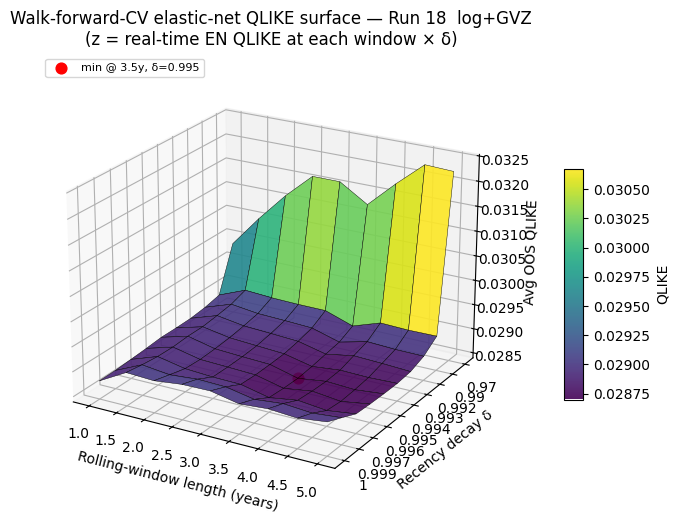

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_99525/3041124247.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


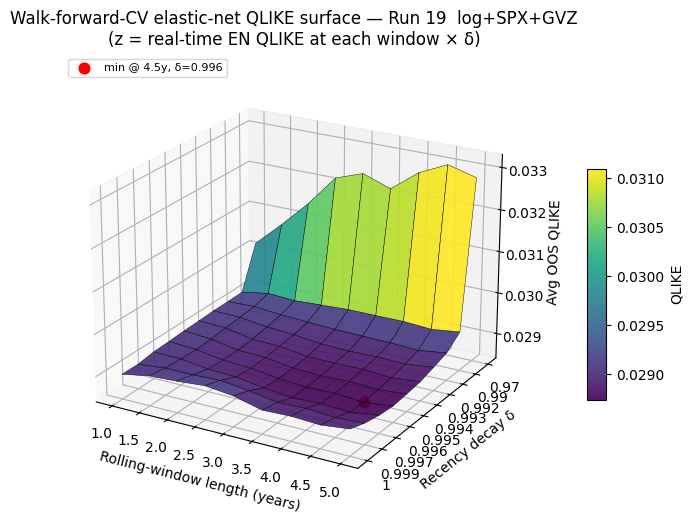

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_99525/3041124247.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


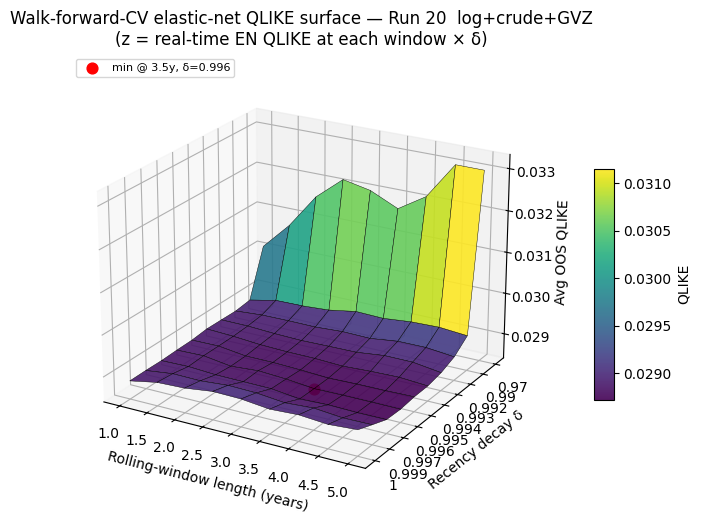

In [7]:
# ===========================================================================
# Cell 7 — 3D QLIKE surfaces: window x delta -> walk-forward-CV EN QLIKE (per spec)
# ===========================================================================
# One surface per spec. x = rolling-window length, y = recency-decay delta, and the
# vertical z = average out-of-sample QLIKE (lower = better). delta is plotted on an
# evenly-spaced axis (its values bunch near 1.0) with tick labels showing the actual
# factor. The red marker is the (window, delta) cell with the lowest QLIKE.
ypos = np.arange(len(DELTAS))                         # even spacing for the delta axis
WIN, DELi = np.meshgrid(WINDOW_YEARS, ypos)          # (n_delta, n_window)

def plot_en_surface(label, df, fname):
    Z = df.to_numpy(dtype=float).T                   # (n_delta, n_window)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection="3d")
    surf = ax.plot_surface(WIN, DELi, Z, cmap="viridis", edgecolor="k",
                           linewidth=0.3, alpha=0.9, antialiased=True)
    # mark the global minimum on the surface
    yr_star = df.min(axis=1).idxmin()
    d_star  = df.loc[yr_star].idxmin()
    q_star  = df.loc[yr_star, d_star]
    ax.scatter([yr_star], [df.columns.get_loc(d_star)], [q_star], color="red", s=60,
               depthshade=False, label=f"min @ {yr_star:.1f}y, δ={d_star}")
    ax.set_xlabel("Rolling-window length (years)")
    ax.set_ylabel("Recency decay δ")
    ax.set_zlabel("Avg OOS QLIKE")
    ax.set_yticks(ypos); ax.set_yticklabels([f"{d:g}" for d in DELTAS])
    ax.set_title(f"Walk-forward-CV elastic-net QLIKE surface — {label}\n"
                 "(z = real-time EN QLIKE at each window × δ)")
    ax.view_init(elev=22, azim=-60)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, pad=0.1, label="QLIKE")
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    plt.show()

fnames = {
    "Run 18  log+GVZ":       "qlike_en_surface_run18.png",
    "Run 19  log+SPX+GVZ":   "qlike_en_surface_run19.png",
    "Run 20  log+crude+GVZ": "qlike_en_surface_run20.png",
}
for label, *_ in specs:
    plot_en_surface(label, en_cube[label], fnames[label])

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_99525/3574687642.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


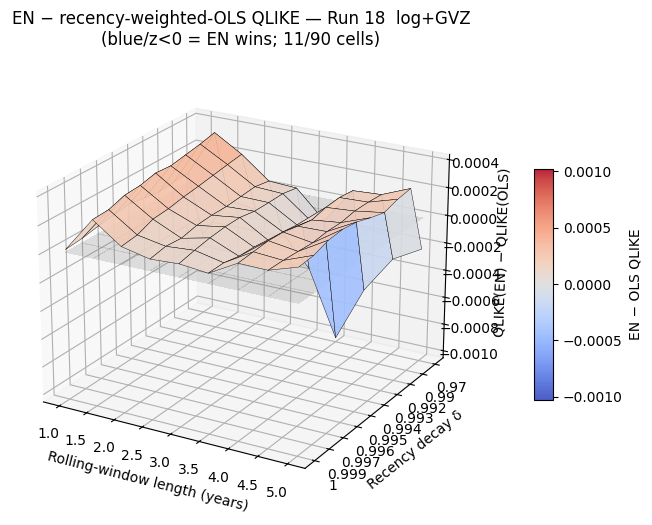

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_99525/3574687642.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


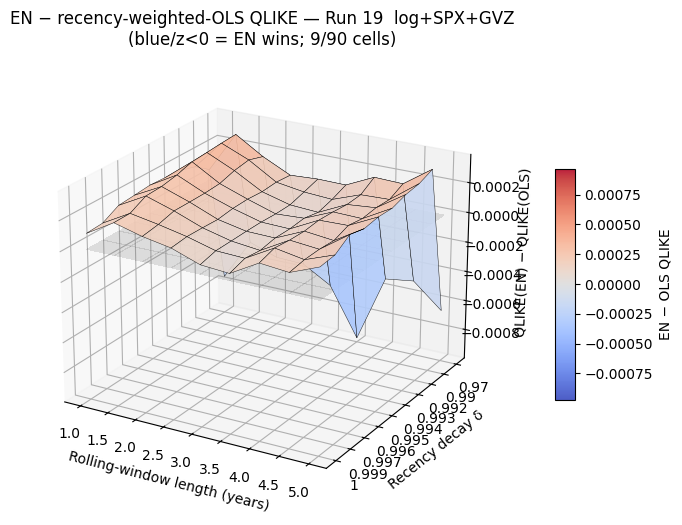

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_99525/3574687642.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


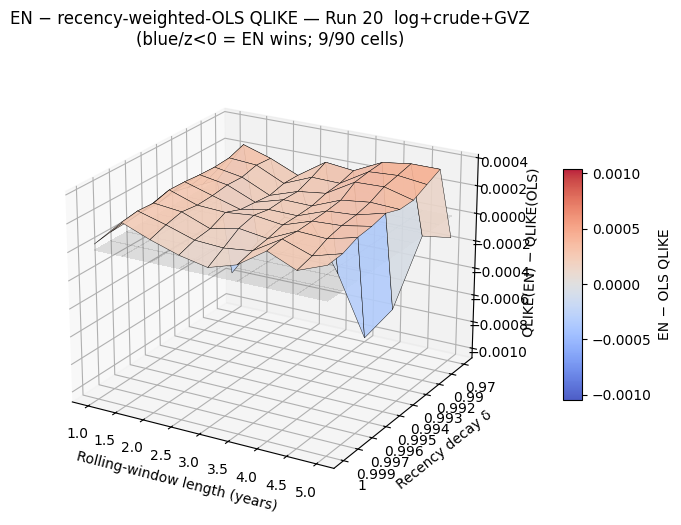

In [8]:
# ===========================================================================
# Cell 8 — EN − OLS difference surfaces: does honest EN beat recency-weighted OLS?
# ===========================================================================
# z = en_cube - ols_cube on the window x delta grid. A translucent z=0 plane marks the
# break-even: cells BELOW it (blue, z<0) are where the walk-forward-CV elastic net beats
# recency-weighted OLS; cells above (red, z>0) are where plain weighted OLS wins.
import matplotlib.colors as mcolors

def plot_diff_surface(label, en_df, ols_df, fname):
    diff = (en_df - ols_df)
    Z = diff.to_numpy(dtype=float).T                 # (n_delta, n_window)
    vmax = np.nanmax(np.abs(Z)); norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection="3d")
    surf = ax.plot_surface(WIN, DELi, Z, cmap="coolwarm", norm=norm, edgecolor="k",
                           linewidth=0.3, alpha=0.9, antialiased=True)
    # translucent break-even plane at z = 0
    ax.plot_surface(WIN, DELi, np.zeros_like(Z), color="grey", alpha=0.18,
                    linewidth=0, antialiased=False)
    ax.set_xlabel("Rolling-window length (years)")
    ax.set_ylabel("Recency decay δ")
    ax.set_zlabel("QLIKE(EN) − QLIKE(OLS)")
    ax.set_yticks(ypos); ax.set_yticklabels([f"{d:g}" for d in DELTAS])
    n_better = int((Z < 0).sum())
    ax.set_title(f"EN − recency-weighted-OLS QLIKE — {label}\n"
                 f"(blue/z<0 = EN wins; {n_better}/{Z.size} cells)")
    ax.view_init(elev=22, azim=-60)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, pad=0.1, label="EN − OLS QLIKE")
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    plt.show()

diff_fnames = {
    "Run 18  log+GVZ":       "qlike_en_minus_ols_run18.png",
    "Run 19  log+SPX+GVZ":   "qlike_en_minus_ols_run19.png",
    "Run 20  log+crude+GVZ": "qlike_en_minus_ols_run20.png",
}
for label, *_ in specs:
    plot_diff_surface(label, en_cube[label], ols_cube[label], diff_fnames[label])